In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Projects\Data\Supply_Chain_dataset.csv")

df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'])
df = df.drop(columns="Order_Zipcode")
df = df.drop(columns="Product_Description")
df = df.drop(columns="Product_Image")
df = df.drop(columns="Customer_Email")
df = df.drop(columns="Product_Status")
df = df.drop(columns="Customer_Password")
df = df.dropna()
df.drop('Order_Profit_Per_Order', axis=1, inplace=True)

duplicate_cols = []
for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_cols.append(df.columns[j])

df = df.drop(columns=duplicate_cols)

In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  str           
 1   Days_for_shipping_(real)       180508 non-null  int64         
 2   Days_for_shipment_(scheduled)  180508 non-null  int64         
 3   Benefit_per_order              180508 non-null  float64       
 4   Sales_per_customer             180508 non-null  float64       
 5   Delivery_Status                180508 non-null  str           
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category_Id                    180508 non-null  int64         
 8   Category_Name                  180508 non-null  str           
 9   Customer_City                  180508 non-null  str           
 10  Customer_Country               180508 non-null  str           
 11  Customer_Fname  

In [38]:
df_Com_Stat= df[df['Order_Status'] == 'COMPLETE']

<Axes: >

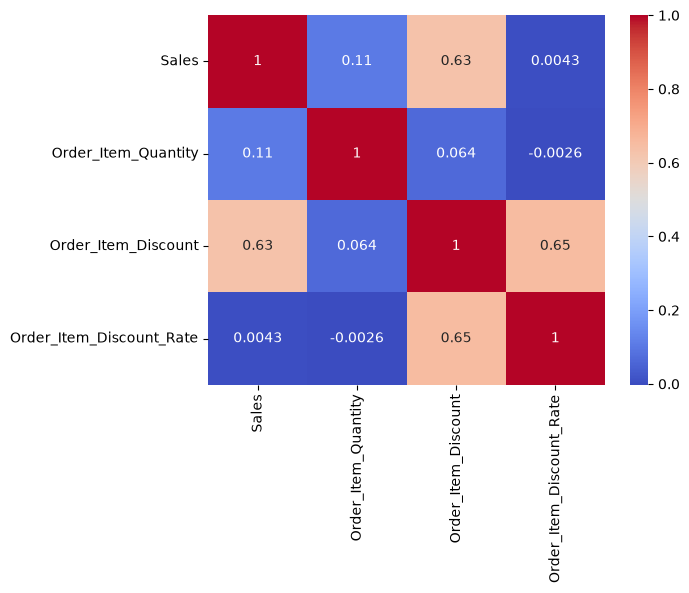

In [39]:
df_h = df_Com_Stat[['Sales', 'Order_Item_Quantity', 'Order_Item_Discount', 'Order_Item_Discount_Rate']].corr()
sns.heatmap(df_h, annot=True, cmap='coolwarm')

<Axes: xlabel='Sales', ylabel='Order_Item_Discount'>

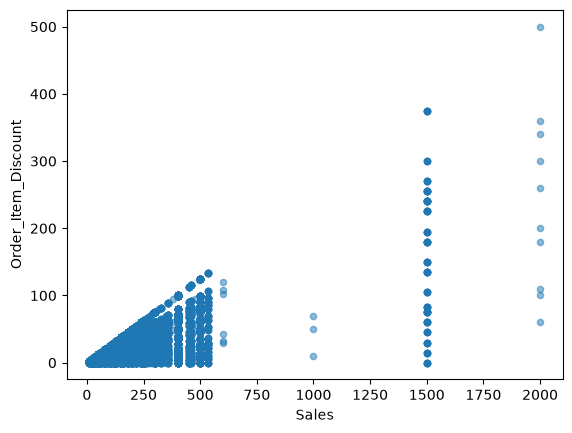

In [40]:
df_Com_Stat.plot.scatter(x='Sales', y='Order_Item_Discount', alpha=0.5)